# this is training the CNNPZ model on the noisy mock data with randomly dropping bands

In [1]:
import sys

from packaging import version
import sklearn
from sklearn.model_selection import KFold, train_test_split

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

#import tensorflow_probability as tfp

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

import pandas as pd
import h5py
import numpy as np

import json
import os

from matplotlib import colors

2026-09-15 01:16:24.483971: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-15 01:16:24.484001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-15 01:16:24.485373: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-15 01:16:24.493450: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-15 01:16:25.846228: W tensorflow/compiler/tf2

In [2]:
import cnnpz_utils as cnnpz

## Pre-defined functions

In [3]:
def _mad(x, M):
    """Median absolute deviation about M (unscaled)."""
    return np.median(np.abs(x - M))


def biweight_location(data, c=6.0, ignore_nan=False):
    """Robust estimate of the centre. Analogue of np.mean."""
    x = np.asarray(data, dtype=float).ravel()
    if ignore_nan:
        x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan

    M = np.median(x)
    mad = _mad(x, M)
    if mad == 0 or not np.isfinite(mad):
        return M

    u = (x - M) / (c * mad)
    mask = np.abs(u) < 1
    if not mask.any():
        return M

    u = u[mask]
    w = (1.0 - u**2) ** 2
    return M + np.sum((x[mask] - M) * w) / np.sum(w)


def biweight_midvariance(data, c=9.0, ignore_nan=False, modify_sample_size=False):
    """Robust estimate of the variance."""
    x = np.asarray(data, dtype=float).ravel()
    if ignore_nan:
        x = x[~np.isnan(x)]
    if x.size == 0:
        return np.nan

    M = np.median(x)
    mad = _mad(x, M)
    if mad == 0 or not np.isfinite(mad):
        return 0.0

    u = (x - M) / (c * mad)
    mask = np.abs(u) < 1
    u = u[mask]

    n = mask.sum() if modify_sample_size else x.size

    f1 = np.sum((x[mask] - M) ** 2 * (1.0 - u**2) ** 4)
    f2 = np.abs(np.sum((1.0 - u**2) * (1.0 - 5.0 * u**2))) ** 2
    if f2 == 0:
        return 0.0
    return n * f1 / f2


def biweight_scale(data, c=9.0, ignore_nan=False, modify_sample_size=False):
    """Robust estimate of the scatter. Analogue of np.std."""
    return np.sqrt(biweight_midvariance(
        data, c=c, ignore_nan=ignore_nan, modify_sample_size=modify_sample_size
    ))


def get_biweight_mean_sigma_outlier(subset, nclip= 3, abs_out_thresh=0.2):
    subset_clip, _, _ = sigmaclip(subset, low=3, high=3)
    for _j in range(nclip):
        subset_clip, _, _ = sigmaclip(subset_clip, low=3, high=3)

    mean = biweight_location(subset_clip)
    std = biweight_scale(subset_clip)
    #mean = np.mean(subset_clip)
    #std = np.std(subset_clip)
    #outlier_rate = np.sum(np.abs(subset) > 3 * biweight_scale(subset_clip)) / len(
    #    subset
    #)
    outlier_rate = np.sum(np.abs(subset) > 3 * np.std(subset_clip)) / len(
        subset
    )
    abs_outlier_rate = np.sum(np.abs(subset) > abs_out_thresh) / len(
        subset
    )

    return (
        mean,
        std / np.sqrt(len(subset_clip)),
        std,
        outlier_rate,
        abs_outlier_rate,
    )



def get_all_stats(y_train, y_pred, imag_data, save=True, saveroot="", redshift_bins = np.linspace(0,2.5,11), imag_bins = np.linspace(18, 25.5,11)):
    Y = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y)/(1+Y)
    stats = get_biweight_mean_sigma_outlier(dz, nclip= 3, abs_out_thresh=0.2)

    # split in terms of i-mags and redshifts
    redshift_stats = []
    imag_stats = []
    for i in range(10):
        ind= (Y > redshift_bins[i]) & (Y < redshift_bins[i+1])
        redshift_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))
        ind= (imag_data > imag_bins[i]) & (imag_data < imag_bins[i+1])
        imag_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))

    if save == True:
        with open(saveroot, "wb") as f:
            pickle.dump([stats, redshift_stats, imag_stats], f)

    return stats, redshift_stats, imag_stats

def read_stats(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    stats, redshift_stats, imag_stats = data
    return stats, redshift_stats, imag_stats


def plot_stats(stats, redshift_stats, imag_stats, y_train, y_pred, redshift_bins, imag_bins, i_mag_data, save_path=None):
    Y  = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y) / (1 + Y)

    fig = plt.figure(figsize=(15, 5))   # ← reduced height; 15/3 = 5 per column → square
    gs  = gridspec.GridSpec(
        2, 3,
        figure=fig,
        height_ratios=[2, 1],
        hspace=0.05,
        wspace=0.35
    )
    
    ax_scatter = fig.add_subplot(gs[:, 0])
    ax_zstats  = fig.add_subplot(gs[0, 1])
    ax_zdz     = fig.add_subplot(gs[1, 1], sharex=ax_zstats)
    ax_istats  = fig.add_subplot(gs[0, 2])
    ax_idz     = fig.add_subplot(gs[1, 2], sharex=ax_istats)
    
    # Only scatter panel needs to be square
    ax_scatter.set_box_aspect(1)    # ← only this one

    # ── Panel 1: scatter plot ────────────────────────────────────────────────
    mean, _mean_err, std, outlier_rate, abs_outlier_rate = stats
    mean, std, outlier_rate, abs_outlier_rate = (
        round(mean, 4), round(std, 4),
        round(outlier_rate, 4), round(abs_outlier_rate, 4)
    )

    #ax_scatter.scatter(y_train, y_pred, s=0.1, color='k')
    bin_edges = np.linspace(0,3,101)
    ax_scatter.hist2d(
        y_train,
        y_pred,
        bins=(bin_edges, bin_edges),
        norm=colors.LogNorm(),
        cmap="gray",
        )
    ax_scatter.plot([0, 3], [0, 3], 'r-')
    ax_scatter.plot([0, 3], [0 - 3*std, 3 - 3*std], 'r--')
    ax_scatter.plot([0, 3], [0 + 3*std, 3 + 3*std], 'r--')
    ax_scatter.set_xlim([0, 3])
    ax_scatter.set_ylim([0, 3])
    ax_scatter.set_xlabel('truth redshift')
    ax_scatter.set_ylabel('predicted redshift')

    abs_out_thresh = 0.2
    label = (
        rf"$\Delta z = {mean}$" + "\n" +
        rf"$\sigma z = {std}$"  + "\n" +
        rf"outlier rate (>3$\sigma$) = {outlier_rate}" + "\n" +
        f"outlier rate (>{abs_out_thresh}) = {abs_outlier_rate}"
    )
    ax_scatter.text(0.1, 1.8, label, fontsize=12,
                   bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # ── Panel 2: redshift statistics ─────────────────────────────────────────
    N_bin  = len(redshift_bins) - 1
    z_mean = np.zeros(N_bin)
    z_err  = np.zeros(N_bin)
    z_std  = np.zeros(N_bin)
    z_out  = np.zeros(N_bin)
    z_abs  = np.zeros(N_bin)
    for i in range(N_bin):
        z_mean[i], z_err[i], z_std[i], z_out[i], z_abs[i] = redshift_stats[i]

    z_centres = (redshift_bins[1:] + redshift_bins[:-1]) / 2
    ax_zstats.plot(z_centres, z_mean, '-', label="bias")
    ax_zstats.plot(z_centres, z_std,  '-', label=r"$\sigma_z$")
    ax_zstats.plot(z_centres, z_out,  '-', label="outlier rate")
    ax_zstats.legend()
    ax_zstats.set_ylabel("statistics")
    plt.setp(ax_zstats.get_xticklabels(), visible=False)

    #ax_zdz.scatter(Y, dz, s=0.1, color='k')
    dzbin_edges = np.linspace(-0.7,0.7,51)
    ax_zdz.hist2d(
        Y,
        dz,
        bins=(bin_edges, dzbin_edges),
        norm=colors.LogNorm(),
        cmap="gray",
        )
    ax_zdz.set_xlabel("redshift")
    ax_zdz.set_ylabel(r"$(z_{pred} - z_{true})/(1 + z_{true})$")
    ax_zdz.set_ylim([-0.5, 0.5])    # ← y-axis limit on lower panel

    # ── Panel 3: i-magnitude statistics ──────────────────────────────────────
    N_bin  = len(imag_bins) - 1
    i_mean = np.zeros(N_bin)
    i_err  = np.zeros(N_bin)
    i_std  = np.zeros(N_bin)
    i_out  = np.zeros(N_bin)
    i_abs  = np.zeros(N_bin)
    for i in range(N_bin):
        i_mean[i], i_err[i], i_std[i], i_out[i], i_abs[i] = imag_stats[i]

    i_centres = (imag_bins[1:] + imag_bins[:-1]) / 2
    ax_istats.plot(i_centres, i_mean, '-', label="bias")
    ax_istats.plot(i_centres, i_std,  '-', label=r"$\sigma_z$")
    ax_istats.plot(i_centres, i_out,  '-', label="outlier rate")
    ax_istats.legend()
    ax_istats.set_ylabel("statistics")
    plt.setp(ax_istats.get_xticklabels(), visible=False)

    #ax_idz.scatter(i_mag_data, dz, s=0.1, color='k')
    ibins = np.linspace(imag_bins[0], imag_bins[-1], 51)
    ax_idz.hist2d(
        i_mag_data,
        dz,
        bins=(ibins, dzbin_edges),
        norm=colors.LogNorm(),
        cmap="gray",
        )
    ax_idz.set_xlabel("i magnitude")
    ax_idz.set_ylabel(r"$(z_{pred} - z_{true})/(1 + z_{true})$")
    ax_idz.set_ylim([-0.5, 0.5])    # ← y-axis limit on lower panel

    plt.suptitle("Photo-z Statistics", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Save if filename provided
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {save_path}")


## Load training and test data, filter curves

In [4]:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "train_100k_noisy_y1_i23.parquet"
training_y1 = pd.read_parquet(fname)
training_y1 = training_y1.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

fname = saveroot + "train_100k_noisy_y10_i25.4.parquet"
training_y10 = pd.read_parquet(fname)
training_y10 = training_y10.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "test_100k_noisy_y1_i23.parquet"
test_y1 = pd.read_parquet(fname)
test_y1 = test_y1.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

fname = saveroot + "test_100k_noisy_y10_i25.4.parquet"
test_y10 = pd.read_parquet(fname)
test_y10 = test_y10.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

### Transform data, make X_train, Y_train, and test dataset, variants of this dataset

In [5]:
# get the LSST and roman filter curves:
filter_root = "/global/homes/j/jaimerz/UCL/rail_base/src/rail/examples_data/estimation_data/data/FILTER/"

wave = {
    "Y":106,
    "J":129,
    "H":158,
}
lsst_filter_curves = {}
roman_filter_curves = {}
for b in "ugrizy":
  lsst_filter_curves[b] = np.loadtxt(filter_root + f'DC2LSST_{b}.res')

for b in "YJH":
  roman_filter_curves[b] = np.loadtxt(filter_root + f'roman_{b}{wave[b]}.res')

# define the wavelength grid
# to begin with, use blocks rather than filter curves
lambda_min = lsst_filter_curves['u'][:,0].min()
lambda_max = roman_filter_curves['H'][:,0].max()
print(lambda_min,lambda_max)

lambda_array = np.linspace(lambda_min,lambda_max,31)
# now let's conver filter curves to blocks: here let's also ignore the big Y band as it overlaps with the y band

3000.0 18650.0


In [6]:
bin_edges = {}
for b in "ugrizyJH":
  if b not in "JH":
    bin_edges[b] = cnnpz.get_bin_edges(lsst_filter_curves[b][:,0])
  else:
    bin_edges[b] = cnnpz.get_bin_edges(roman_filter_curves[b][:,0])
new_edges = lambda_array

rebinned_filters={}
for b in "ugrizyJH":
  if b not in "JH":
    counts = lsst_filter_curves[b][:,1]
  else:
    counts = roman_filter_curves[b][:,1]
  rebinned_filters[b] = cnnpz.rebin_filter(bin_edges[b], counts, new_edges)

lambda_array_cen = (new_edges[1:] + new_edges[:-1])/2
dlambda = new_edges[1] - new_edges[0]
#for b in "ugrizyJH":
#  plt.plot(lambda_array_cen, rebinned_filters[b],'.-')

# further convert this to blocks:
# let's take 1 when the current filter value is > next filter
filter_blocks={}
bands = "ugrizyJH"
for i, b in enumerate("ugrizyJ"):
  if i>0:
    filter_blocks[b] = (rebinned_filters[b] >= rebinned_filters[bands[i+1]]) & (rebinned_filters[b] > rebinned_filters[bands[i-1]])
  else:
    filter_blocks[b] = (rebinned_filters[b] > rebinned_filters[bands[i+1]])
filter_blocks['H'] = (rebinned_filters['H'] > rebinned_filters['J']) & (rebinned_filters['H'] > rebinned_filters['y'])

In [7]:
X_y1, Y_y1 = cnnpz.transform_data_to_XY(training_y1, lambda_array_cen, filter_blocks, apply_stretch = False)
X_test_y1, Y_test_y1 = cnnpz.transform_data_to_XY(test_y1, lambda_array_cen, filter_blocks, apply_stretch = False)

X_y10, Y_y10 = cnnpz.transform_data_to_XY(training_y10, lambda_array_cen, filter_blocks, apply_stretch = False)
X_test_y10, Y_test_y10 = cnnpz.transform_data_to_XY(test_y10, lambda_array_cen, filter_blocks, apply_stretch = False)

In [8]:
print(X_y1.shape, Y_y1.shape)

(107444, 30, 3) (107444,)


## Making datasets with missing bands - NIR removal

In [9]:
# let's construct a dataset where half of the sample do not have NIR measurements:
X_y1_misnir, Y_y1_misnir = cnnpz.make_incomplete_nir_data(training_y1, lambda_array_cen, filter_blocks, apply_stretch = False)
X_test_y1_misnir, Y_test_y1_misnir = cnnpz.make_incomplete_nir_data(test_y1, lambda_array_cen, filter_blocks, apply_stretch = False)

X_y10_misnir, Y_y10_misnir = cnnpz.make_incomplete_nir_data(training_y10, lambda_array_cen, filter_blocks, apply_stretch = False)
X_test_y10_misnir, Y_test_y10_misnir = cnnpz.make_incomplete_nir_data(test_y10, lambda_array_cen, filter_blocks, apply_stretch = False)

# visualize the data

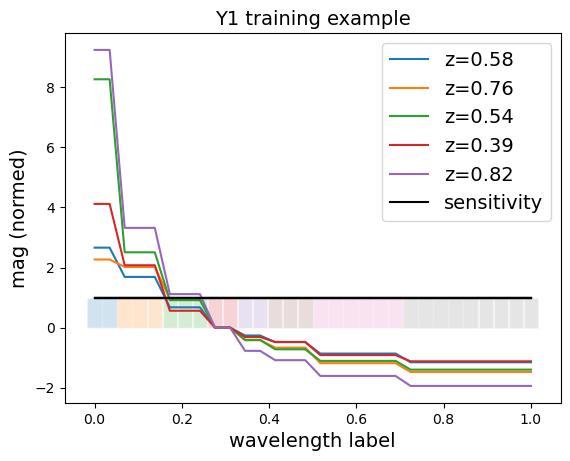

In [10]:
cnnpz.visualize_the_data(X_y1, Y_y1, lambda_array_cen, filter_blocks, title="Y1 training example")

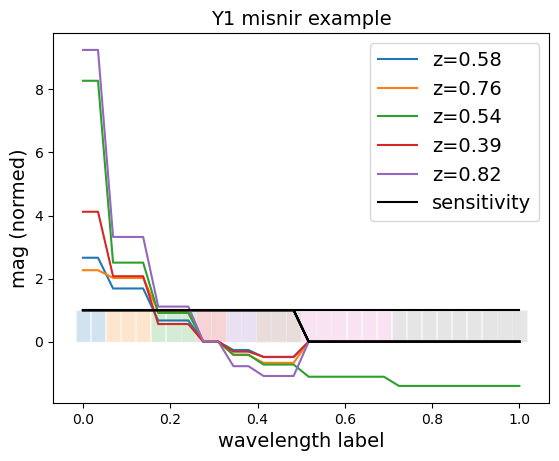

In [11]:
cnnpz.visualize_the_data(X_y1_misnir, Y_y1_misnir, lambda_array_cen, filter_blocks, title="Y1 misnir example")

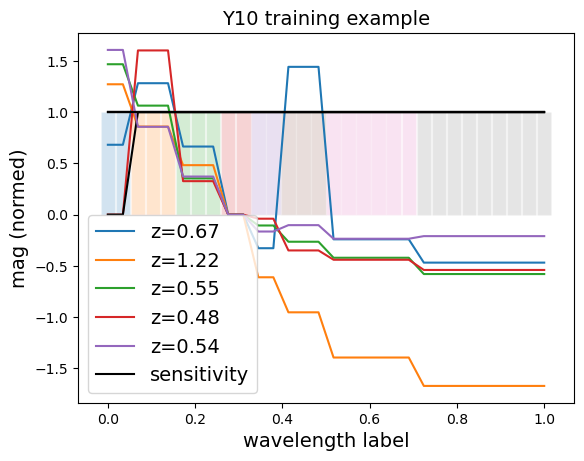

In [12]:
cnnpz.visualize_the_data(X_y10, Y_y10, lambda_array_cen, filter_blocks, title="Y10 training example")

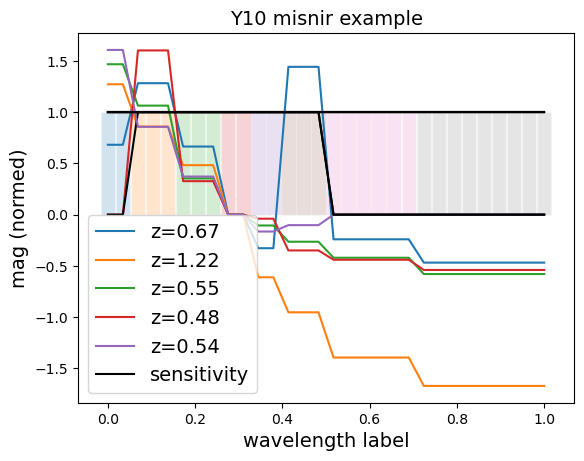

In [13]:
cnnpz.visualize_the_data(X_y10_misnir, Y_y10_misnir, lambda_array_cen, filter_blocks, title="Y10 misnir example")

# training ensemble model

In [17]:
# train on Y1 complete
from cnnpz_utils import build_model
trained_models, histories = cnnpz.train_ensembles(build_model, X_y1, Y_y1)


--- Fold 1/5 ---


2026-09-15 01:20:13.066704: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38478 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2026-09-15 01:20:13.068394: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38478 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2026-09-15 01:20:13.069986: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 38478 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0
2026-09-15 01:20:13.071417: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 38478 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-40GB, pci bu

Epoch 1/100


2026-09-15 01:20:14.874354: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903
2026-09-15 01:20:17.789214: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f9324ced6a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-15 01:20:17.789229: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-09-15 01:20:17.789237: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-09-15 01:20:17.789244: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-09-15 01:20:17.789250: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (3): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-09-15 01:20:17.796795: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_u

336/336 - 9s - loss: 0.0025 - val_loss: 4.2297e-04 - lr: 0.0010 - 9s/epoch - 27ms/step
Epoch 2/100
336/336 - 1s - loss: 9.2010e-04 - val_loss: 4.1461e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
336/336 - 1s - loss: 6.2712e-04 - val_loss: 3.0413e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
336/336 - 1s - loss: 5.2768e-04 - val_loss: 2.1952e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
336/336 - 1s - loss: 4.9986e-04 - val_loss: 2.4387e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
336/336 - 1s - loss: 4.7064e-04 - val_loss: 2.3044e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
336/336 - 1s - loss: 4.2117e-04 - val_loss: 1.8732e-04 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 8/100
336/336 - 1s - loss: 4.1723e-04 - val_loss: 2.0861e-04 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 9/100
336/336 - 1s - loss: 4.2095e-04 - val_loss: 2.3604e-04 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 10

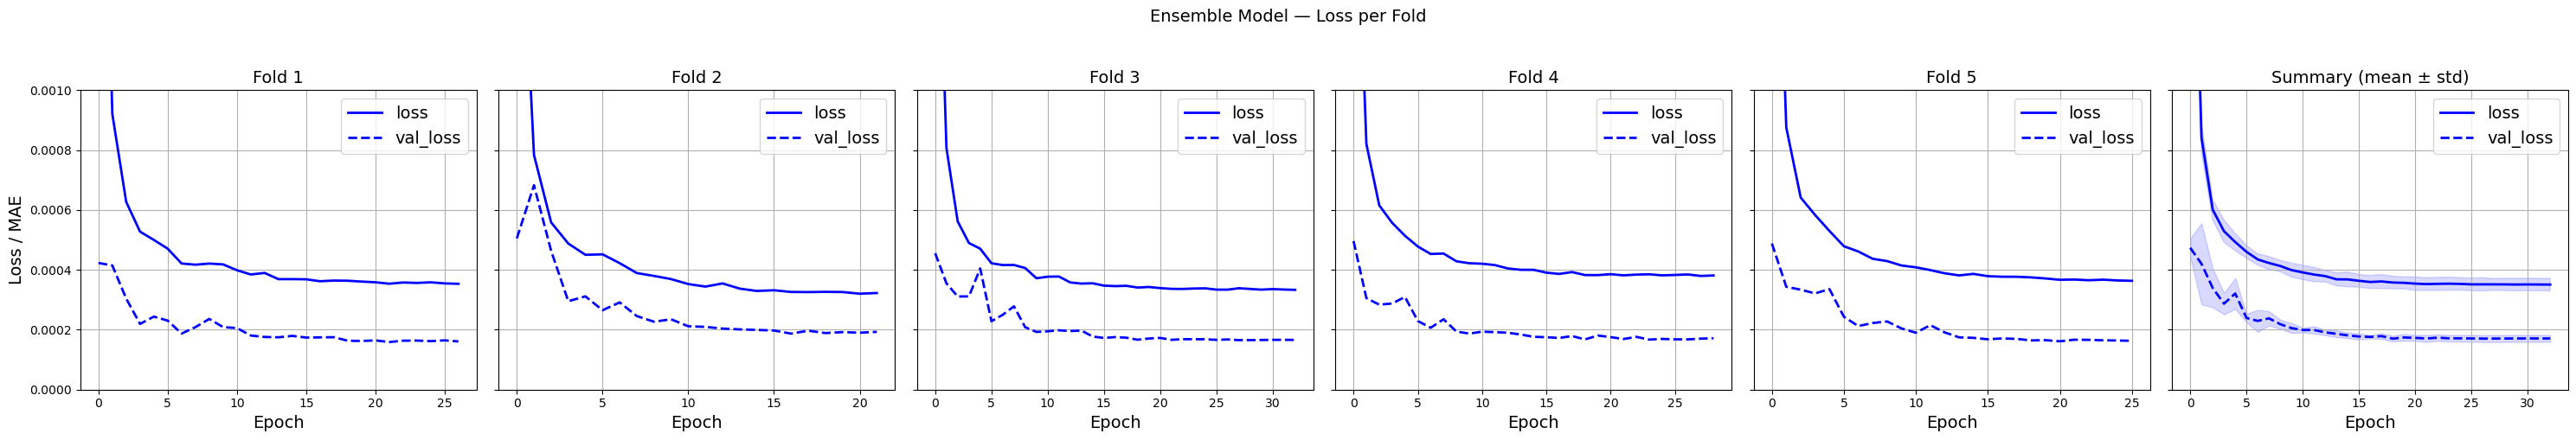

In [18]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.001))

In [19]:
# save the trained model:
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y1_complete_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/norm_params.json


In [20]:
# load the model:
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y1_complete_ensemble_CNN_6layers"
trained_models = cnnpz.load_ensemble(save_dir=save_dir)

Loaded fold 1 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_1.keras
Loaded fold 2 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_2.keras
Loaded fold 3 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_3.keras
Loaded fold 4 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_4.keras
Loaded fold 5 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_5.keras


In [21]:
# Final prediction on test set
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test_y1)

3338/3338 [==============================] - 4s 1ms/step


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

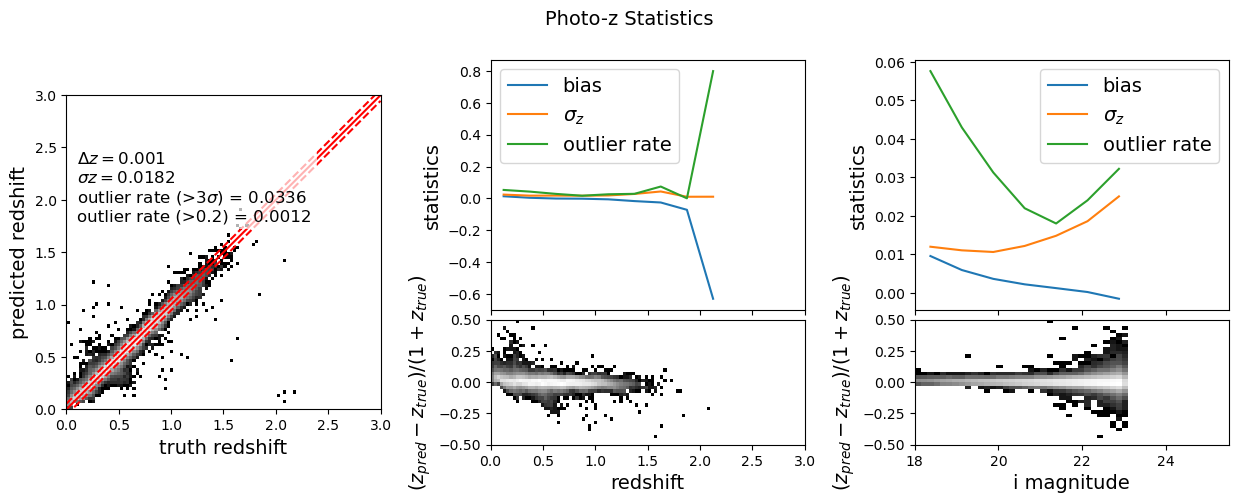

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [22]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y1, y_pred_ensemble.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

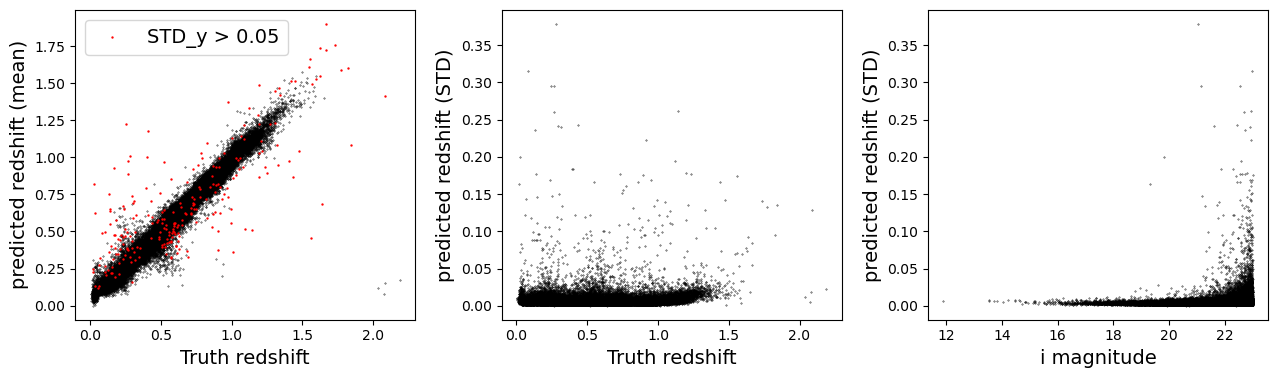

In [30]:
# also plot the STD as a function of redshift and i-band magnitude:
fig,axarr=plt.subplots(1,3,figsize=[13,4])
plt.sca(axarr[0])
ind = y_pred_STD.flatten() >= 0.05
plt.scatter(Y_test_y1[~ind], y_pred_ensemble.flatten()[~ind], s=0.1, color='k')
plt.scatter(Y_test_y1[ind], y_pred_ensemble.flatten()[ind], s=0.5, color='r', label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()

plt.sca(axarr[1])
plt.scatter(Y_test_y1, y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(test_y1['mag_i_lsst'], y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

In [24]:
# now let's train on the data with dropped bands:
trained_models, histories = cnnpz.train_ensembles(build_model, X_y1_misnir, Y_y1_misnir)


--- Fold 1/5 ---
Epoch 1/100
336/336 - 3s - loss: 0.0036 - val_loss: 5.9131e-04 - lr: 0.0010 - 3s/epoch - 10ms/step
Epoch 2/100
336/336 - 1s - loss: 0.0012 - val_loss: 4.8848e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
336/336 - 1s - loss: 8.9983e-04 - val_loss: 4.0326e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
336/336 - 1s - loss: 7.4034e-04 - val_loss: 5.3590e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
336/336 - 1s - loss: 6.6003e-04 - val_loss: 3.7468e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
336/336 - 1s - loss: 6.1712e-04 - val_loss: 3.8361e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
336/336 - 1s - loss: 5.9654e-04 - val_loss: 3.3192e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
336/336 - 1s - loss: 5.7053e-04 - val_loss: 3.4275e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 9/100
336/336 - 1s - loss: 5.2772e-04 - val_loss: 3.0709e-04 - lr: 5.0000e-04 - 1s/epoch -

In [25]:
y_pred_ensemble_misnir, y_pred_STD_misnir = cnnpz.ensemble_predict(trained_models, X_test_y1_misnir)

3338/3338 [==============================] - 4s 1ms/step


In [26]:
# save the trained model:
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y1_misnir_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/norm_params.json


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

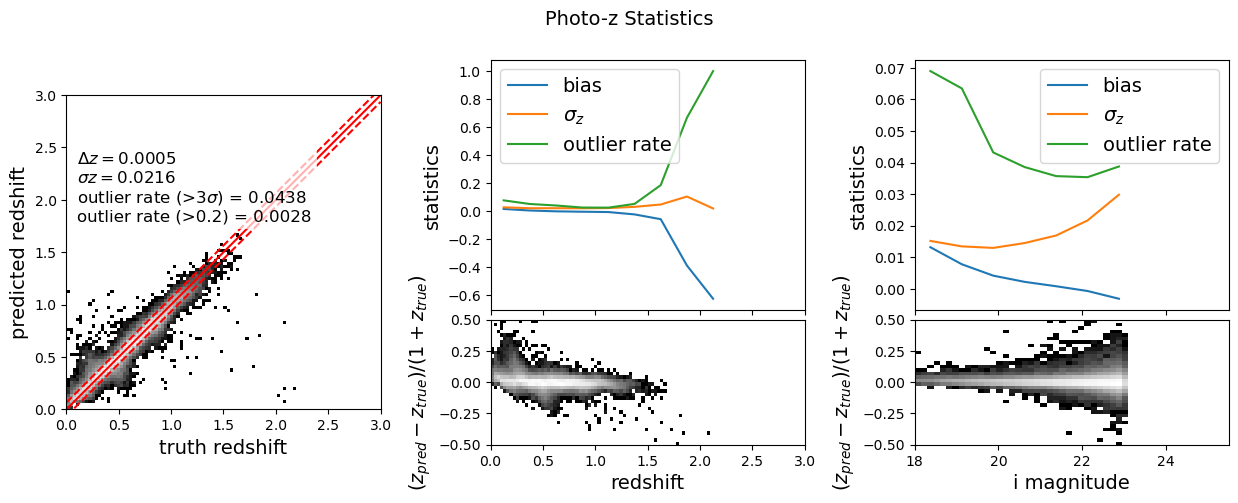

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [27]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y1_misnir, y_pred_ensemble_misnir.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1_misnir, y_pred_ensemble_misnir.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

In [28]:
# let's apply the complete test data on the model trained with incomplete data
y_pred_ensemble2, y_pred_STD2= cnnpz.ensemble_predict(trained_models, X_test_y1)

3338/3338 [==============================] - 4s 1ms/step


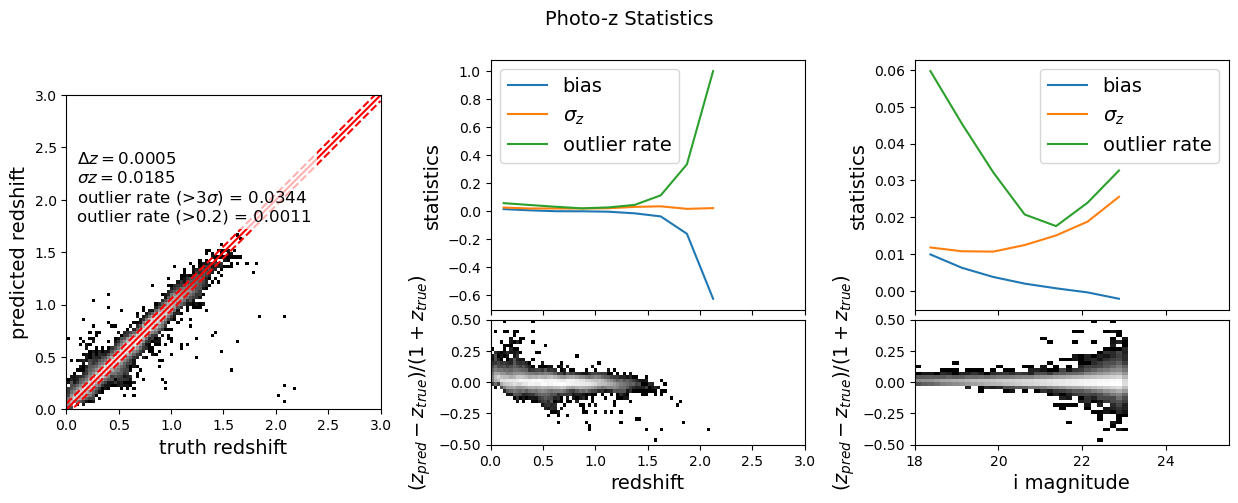

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [29]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y1, y_pred_ensemble2.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1, y_pred_ensemble2.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

## Cardinal Y10

In [31]:
trained_models, histories = cnnpz.train_ensembles(build_model, X_y10, Y_y10)


--- Fold 1/5 ---
Epoch 1/100
358/358 - 4s - loss: 0.0052 - val_loss: 0.0020 - lr: 0.0010 - 4s/epoch - 11ms/step
Epoch 2/100
358/358 - 1s - loss: 0.0030 - val_loss: 0.0017 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
358/358 - 2s - loss: 0.0024 - val_loss: 0.0017 - lr: 0.0010 - 2s/epoch - 4ms/step
Epoch 4/100
358/358 - 1s - loss: 0.0022 - val_loss: 0.0016 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
358/358 - 1s - loss: 0.0021 - val_loss: 0.0016 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
358/358 - 1s - loss: 0.0020 - val_loss: 0.0014 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 7/100
358/358 - 1s - loss: 0.0019 - val_loss: 0.0014 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 8/100
358/358 - 1s - loss: 0.0019 - val_loss: 0.0015 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
358/358 - 2s - loss: 0.0019 - val_loss: 0.0013 - lr

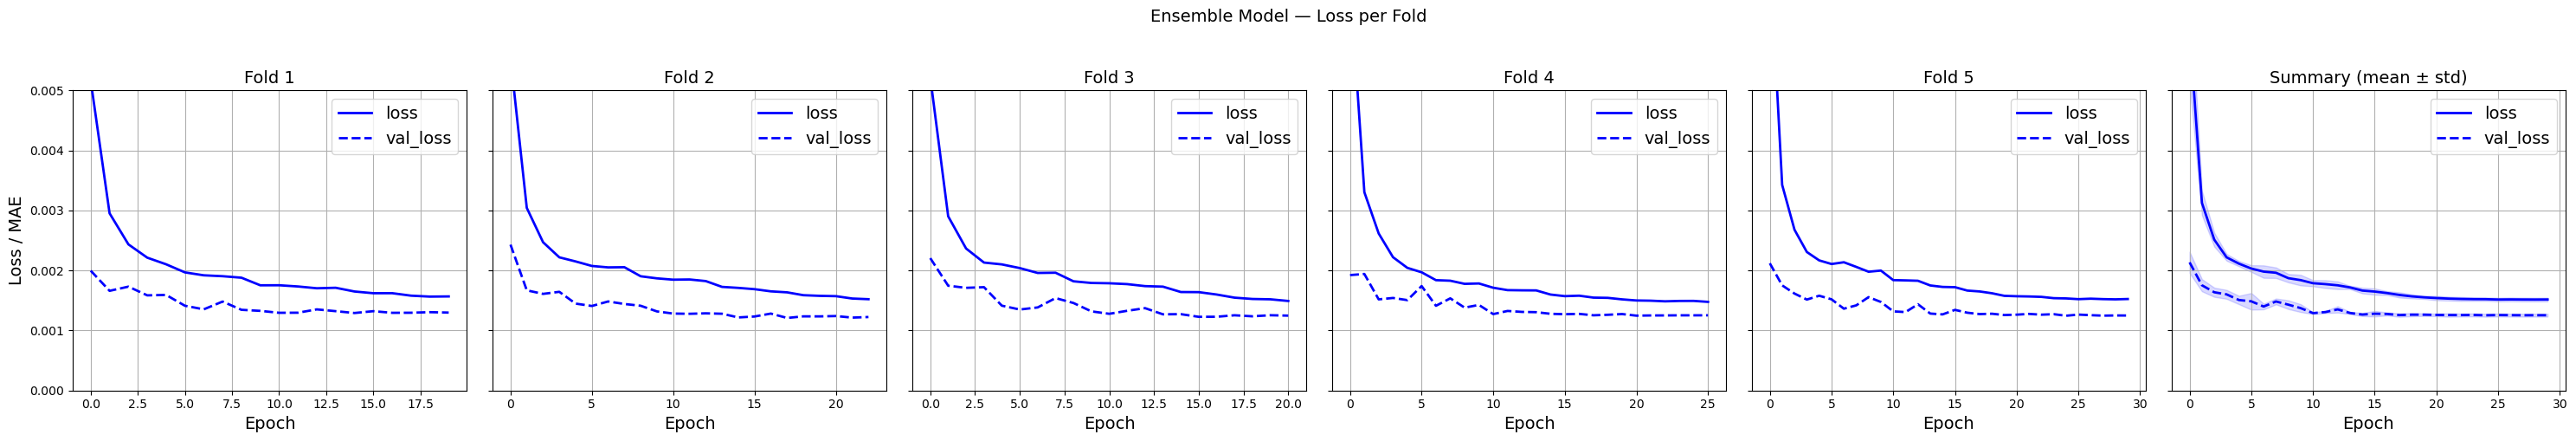

In [32]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.005))

In [33]:
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test_y10)

3582/3582 [==============================] - 4s 1ms/step


In [34]:
# save the trained model:
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_complete_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/norm_params.json


/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/cnnpz_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


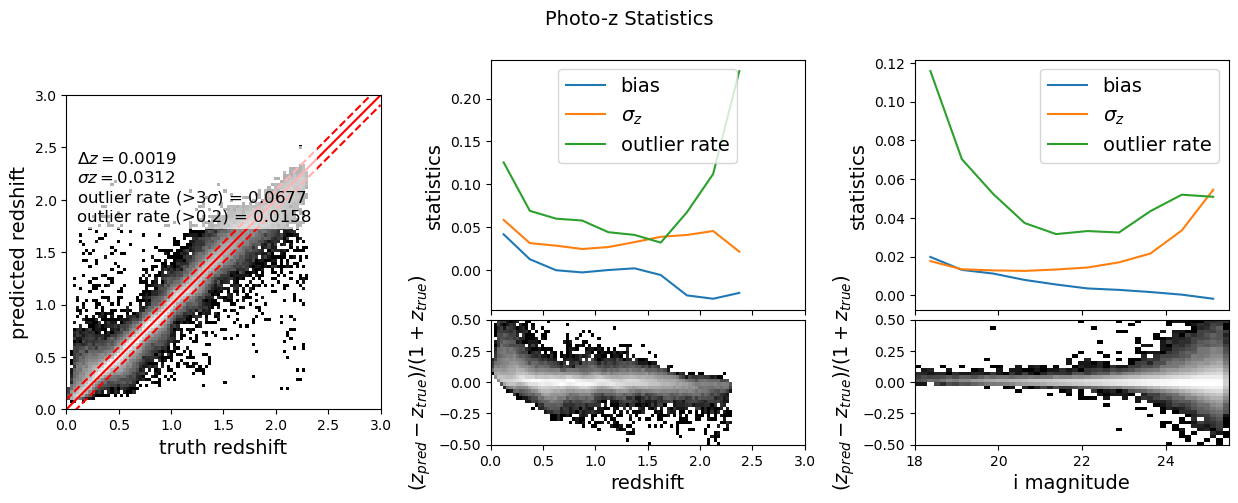

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [35]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y10, y_pred_ensemble.flatten(), test_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y10, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

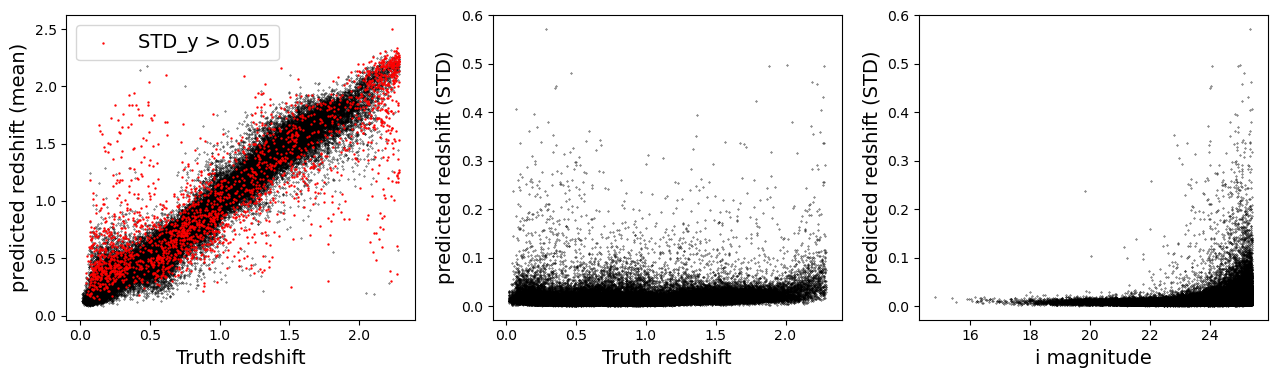

In [36]:
# also plot the STD as a function of redshift and i-band magnitude:
fig,axarr=plt.subplots(1,3,figsize=[13,4])
plt.sca(axarr[0])
ind = y_pred_STD.flatten() >= 0.05
plt.scatter(Y_test_y10[~ind], y_pred_ensemble.flatten()[~ind], s=0.1, color='k')
plt.scatter(Y_test_y10[ind], y_pred_ensemble.flatten()[ind], s=0.5, color='r', label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()

plt.sca(axarr[1])
plt.scatter(Y_test_y10, y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(test_y10['mag_i_lsst'], y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

In [38]:
# try applying this model to the specsel data: is this consistent?
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_complete_ensemble_CNN_6layers"
trained_models = cnnpz.load_ensemble(save_dir=save_dir)

Loaded fold 1 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_1.keras
Loaded fold 2 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_2.keras
Loaded fold 3 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_3.keras
Loaded fold 4 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_4.keras
Loaded fold 5 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_5.keras


In [45]:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
training_y10_spec = pd.read_parquet(saveroot + "train_100k_noisy_y10_i25.4.SpecSelect.parquet")
# change the name of the roman columns:
training_y10_spec = training_y10_spec.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

X_y10_spec, Y_y10_spec = cnnpz.transform_data_to_XY(training_y10_spec, lambda_array_cen, filter_blocks, apply_stretch=False)
y_pred_ensemble_spec, y_pred_STD_spec = cnnpz.ensemble_predict(trained_models, X_y10_spec)

3125/3125 [==============================] - 3s 1ms/step


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

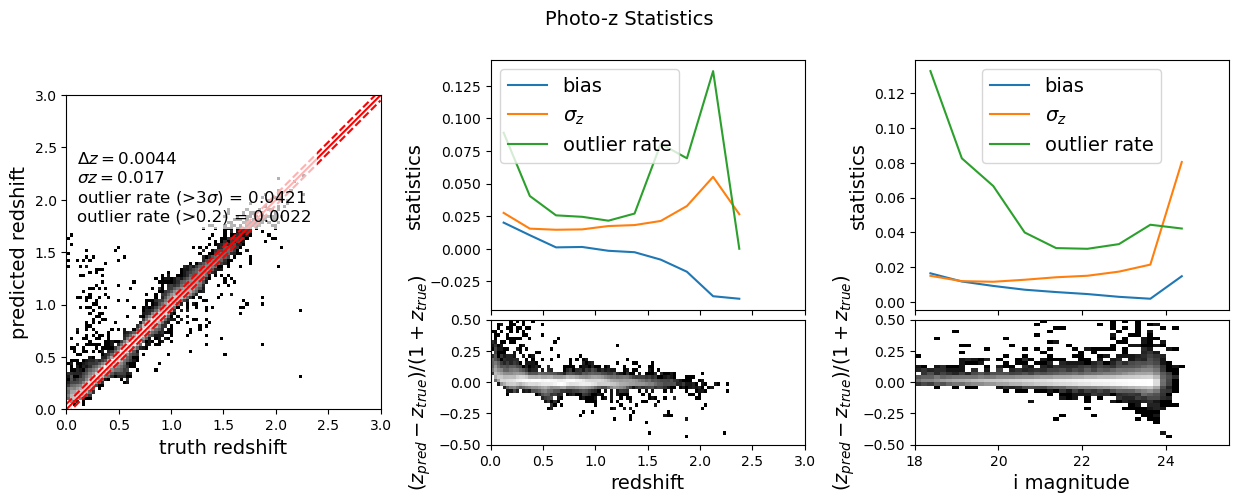

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [46]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_y10_spec, y_pred_ensemble_spec.flatten(), 
                                                     training_y10_spec['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_y10_spec, y_pred_ensemble_spec.flatten(), 
           redshift_bins, imag_bins, training_y10_spec['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

This works well on the spec selected sample!

## dropping nir data

In [47]:
trained_models, histories = cnnpz.train_ensembles(build_model, X_y10_misnir, Y_y10_misnir)


--- Fold 1/5 ---
Epoch 1/100
358/358 - 3s - loss: 0.0081 - val_loss: 0.0048 - lr: 0.0010 - 3s/epoch - 9ms/step
Epoch 2/100
358/358 - 1s - loss: 0.0055 - val_loss: 0.0043 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
358/358 - 1s - loss: 0.0050 - val_loss: 0.0048 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
358/358 - 1s - loss: 0.0047 - val_loss: 0.0040 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
358/358 - 1s - loss: 0.0046 - val_loss: 0.0042 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
358/358 - 1s - loss: 0.0044 - val_loss: 0.0042 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
358/358 - 1s - loss: 0.0044 - val_loss: 0.0042 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100
358/358 - 1s - loss: 0.0042 - val_loss: 0.0038 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 9/100
358/358 - 1s - loss: 0.0041 - val_loss: 0.0037 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 10/100
358/358 - 1s - loss: 0.0041 - val_loss

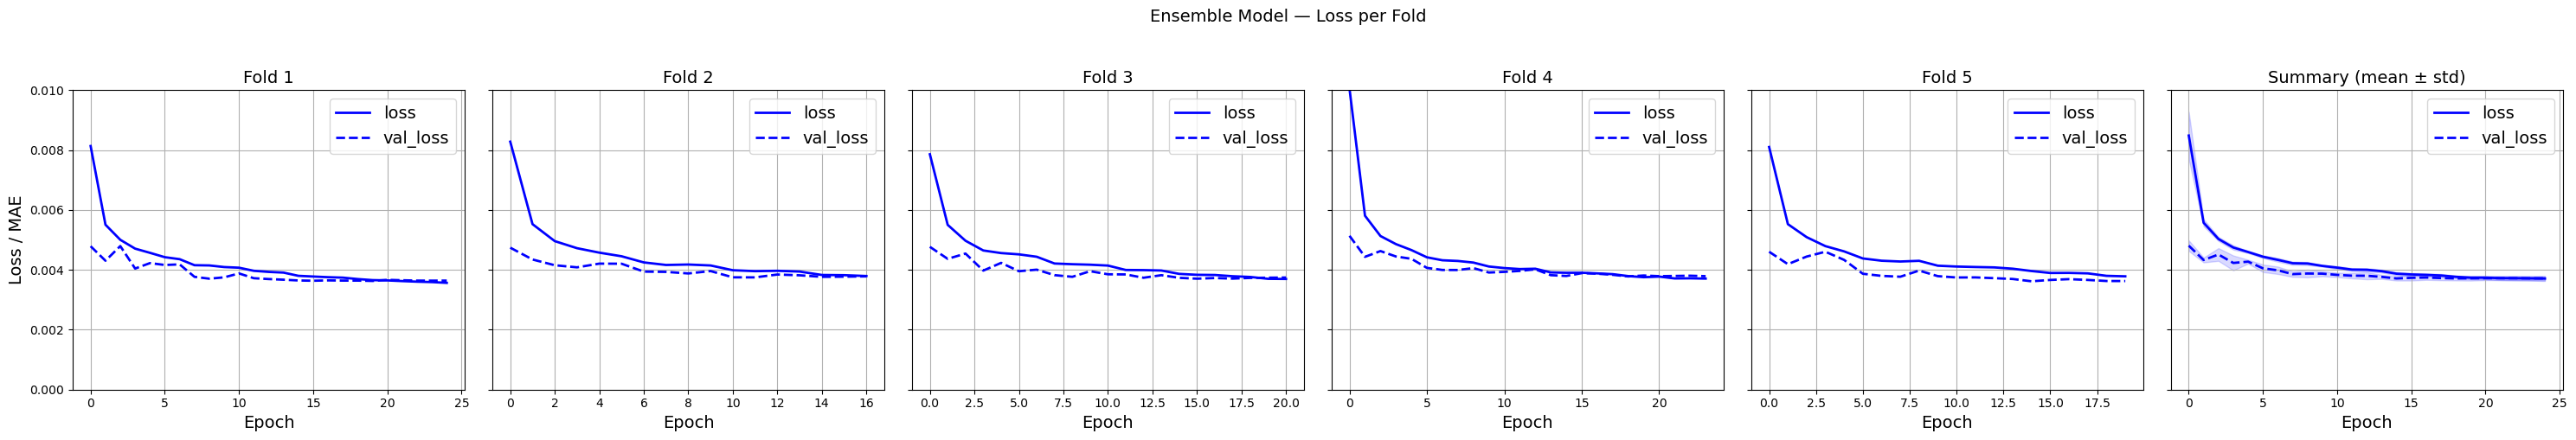

In [49]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.01))

In [50]:
# save the trained model:
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_misnir_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/norm_params.json


In [51]:
# try applying this model to the specsel data: is this consistent?
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_misnir_ensemble_CNN_6layers"
trained_models = cnnpz.load_ensemble(save_dir=save_dir)

Loaded fold 1 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_1.keras
Loaded fold 2 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_2.keras
Loaded fold 3 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_3.keras
Loaded fold 4 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_4.keras
Loaded fold 5 model from /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_5.keras


In [52]:
y_pred_ensemble_misnir, y_pred_STD_misnir = cnnpz.ensemble_predict(trained_models, X_test_y10_misnir)

3582/3582 [==============================] - 4s 1ms/step


/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/cnnpz_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


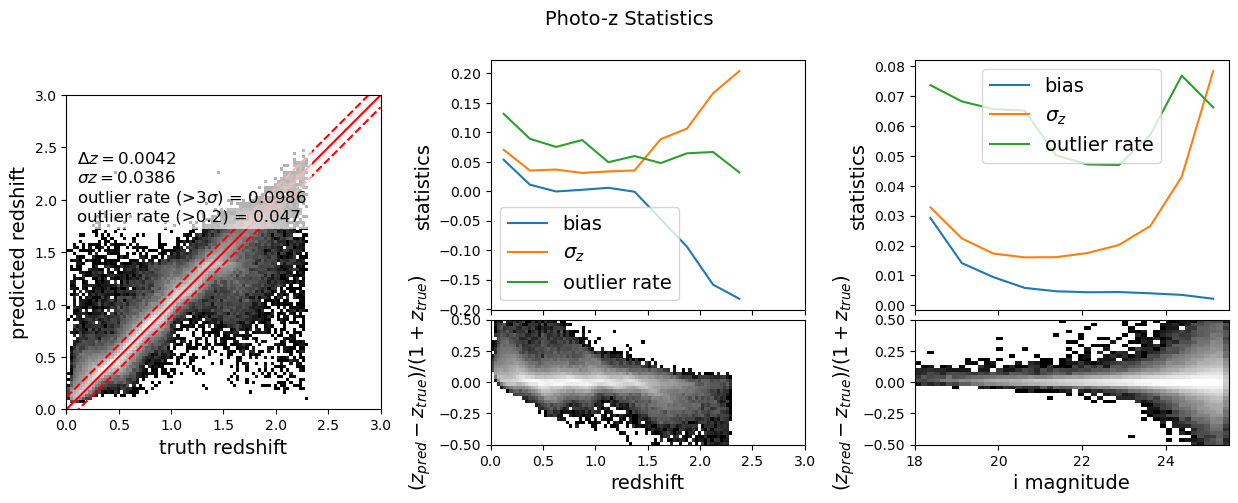

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [53]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y10_misnir, y_pred_ensemble_misnir.flatten(), test_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y10_misnir, y_pred_ensemble_misnir.flatten(), 
           redshift_bins, imag_bins, test_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

## Spec select sample (no pre-training):

In [56]:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
training_y10_spec = pd.read_parquet(saveroot + "train_100k_noisy_y10_i25.4.SpecSelect.parquet")
# change the name of the roman columns:
training_y10_spec = training_y10_spec.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})
training_y10_spec = training_y10_spec.reset_index(drop=True) 
X_y10_spec, Y_y10_spec = cnnpz.transform_data_to_XY(training_y10_spec, lambda_array_cen, filter_blocks, apply_stretch=False)


saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
training_y1_spec = pd.read_parquet(saveroot + "train_100k_noisy_y1_i23.SpecSelect.parquet")
# change the name of the roman columns:
training_y1_spec = training_y1_spec.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})
training_y1_spec = training_y1_spec.reset_index(drop=True) 
X_y1_spec, Y_y1_spec = cnnpz.transform_data_to_XY(training_y1_spec, lambda_array_cen, filter_blocks, apply_stretch=False)

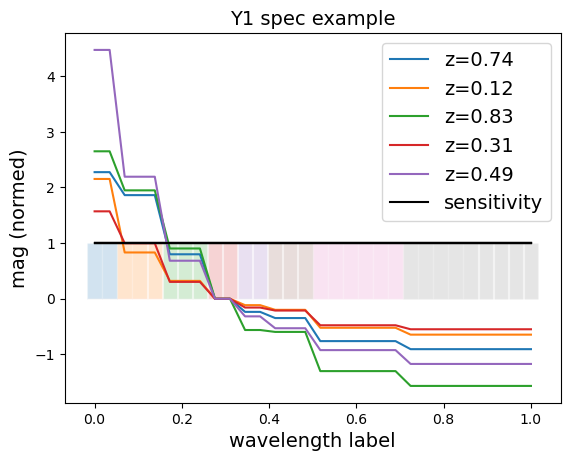

In [61]:
cnnpz.visualize_the_data(X_y1_spec, Y_y1_spec, lambda_array_cen, filter_blocks, title="Y1 spec example")

In [58]:
trained_models, histories = cnnpz.train_ensembles(build_model, X_y1_spec, Y_y1_spec)


--- Fold 1/5 ---
Epoch 1/100
231/231 - 3s - loss: 0.0031 - val_loss: 6.0725e-04 - lr: 0.0010 - 3s/epoch - 14ms/step
Epoch 2/100
231/231 - 1s - loss: 0.0012 - val_loss: 4.6844e-04 - lr: 0.0010 - 936ms/epoch - 4ms/step
Epoch 3/100
231/231 - 1s - loss: 9.0676e-04 - val_loss: 4.2496e-04 - lr: 0.0010 - 952ms/epoch - 4ms/step
Epoch 4/100
231/231 - 1s - loss: 7.1908e-04 - val_loss: 3.0376e-04 - lr: 0.0010 - 977ms/epoch - 4ms/step
Epoch 5/100
231/231 - 1s - loss: 6.2507e-04 - val_loss: 2.7301e-04 - lr: 0.0010 - 934ms/epoch - 4ms/step
Epoch 6/100
231/231 - 1s - loss: 5.3073e-04 - val_loss: 3.0920e-04 - lr: 0.0010 - 914ms/epoch - 4ms/step
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
231/231 - 1s - loss: 5.3329e-04 - val_loss: 2.4777e-04 - lr: 0.0010 - 935ms/epoch - 4ms/step
Epoch 8/100
231/231 - 1s - loss: 4.8669e-04 - val_loss: 2.3035e-04 - lr: 5.0000e-04 - 922ms/epoch - 4ms/step
Epoch 9/100
231/231 - 1s - loss: 4.7217e-04 - val_loss: 2.3786e-04 - lr

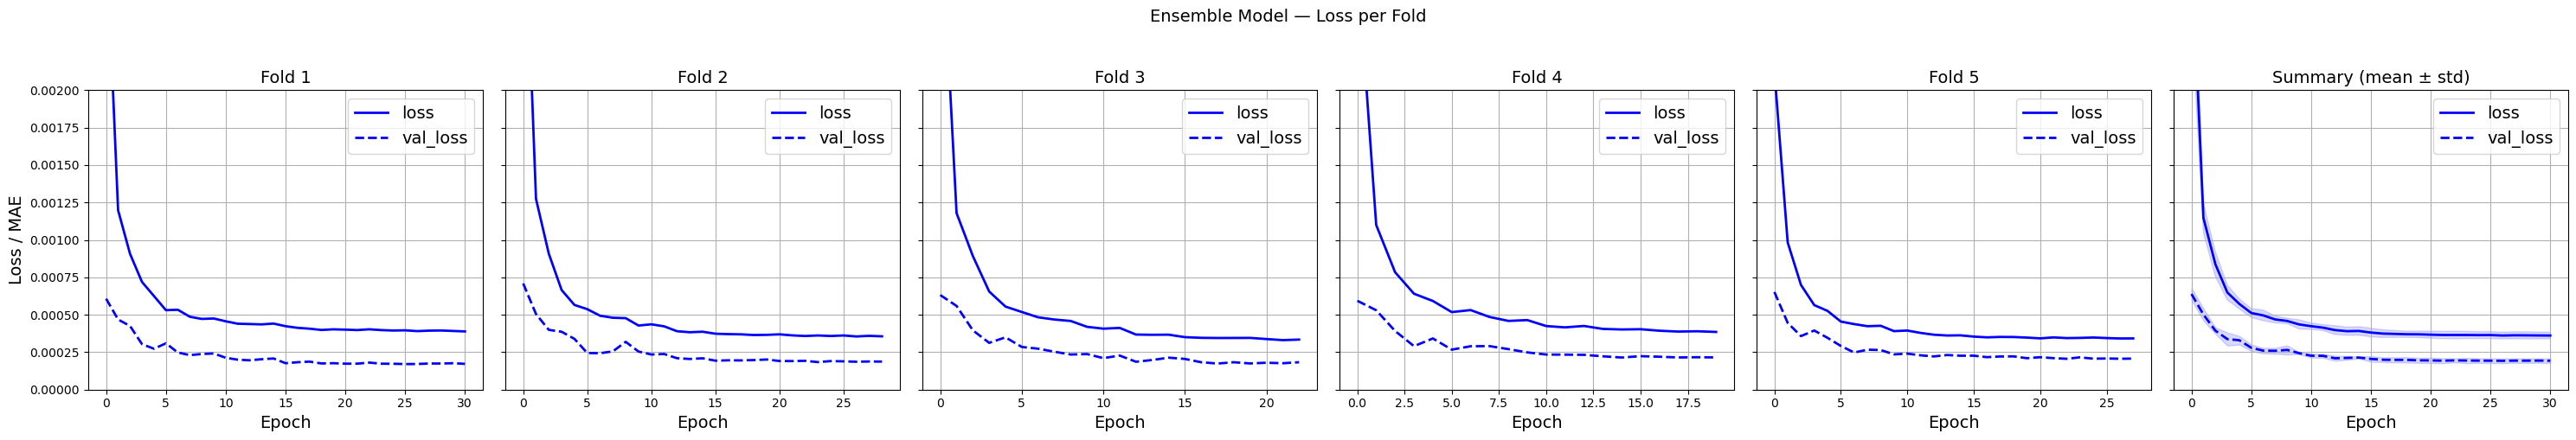

In [59]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.002))

In [60]:
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test_y1)

3338/3338 [==============================] - 4s 1ms/step


In [62]:
# save the trained model:
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y1_specsel_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/norm_params.json


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

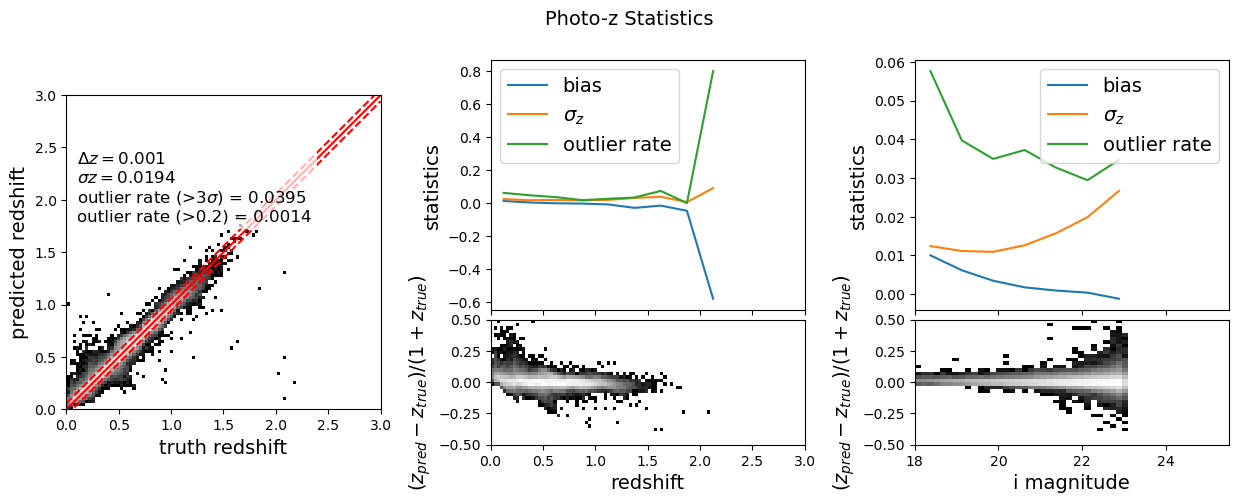

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [63]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y1, y_pred_ensemble.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

### Y10

In [64]:
trained_models, histories = cnnpz.train_ensembles(build_model, X_y10_spec, Y_y10_spec)


--- Fold 1/5 ---
Epoch 1/100
313/313 - 4s - loss: 0.0047 - val_loss: 5.9055e-04 - lr: 0.0010 - 4s/epoch - 12ms/step
Epoch 2/100
313/313 - 1s - loss: 0.0013 - val_loss: 5.5060e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
313/313 - 1s - loss: 9.6699e-04 - val_loss: 2.9207e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
313/313 - 1s - loss: 7.6889e-04 - val_loss: 2.1995e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
313/313 - 1s - loss: 6.5053e-04 - val_loss: 2.2229e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 - 1s - loss: 6.1491e-04 - val_loss: 3.2159e-04 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
313/313 - 1s - loss: 5.5110e-04 - val_loss: 2.0401e-04 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 8/100
313/313 - 1s - loss: 5.2716e-04 - val_loss: 2.1708e-04 - lr: 5.0000e-04 - 1s/epoch - 4ms/step
Epoch 9/100
313/313 - 1s - loss: 5.2147e-04 - val_loss: 1.5671e-04 - lr: 5.0000e-04 - 1s

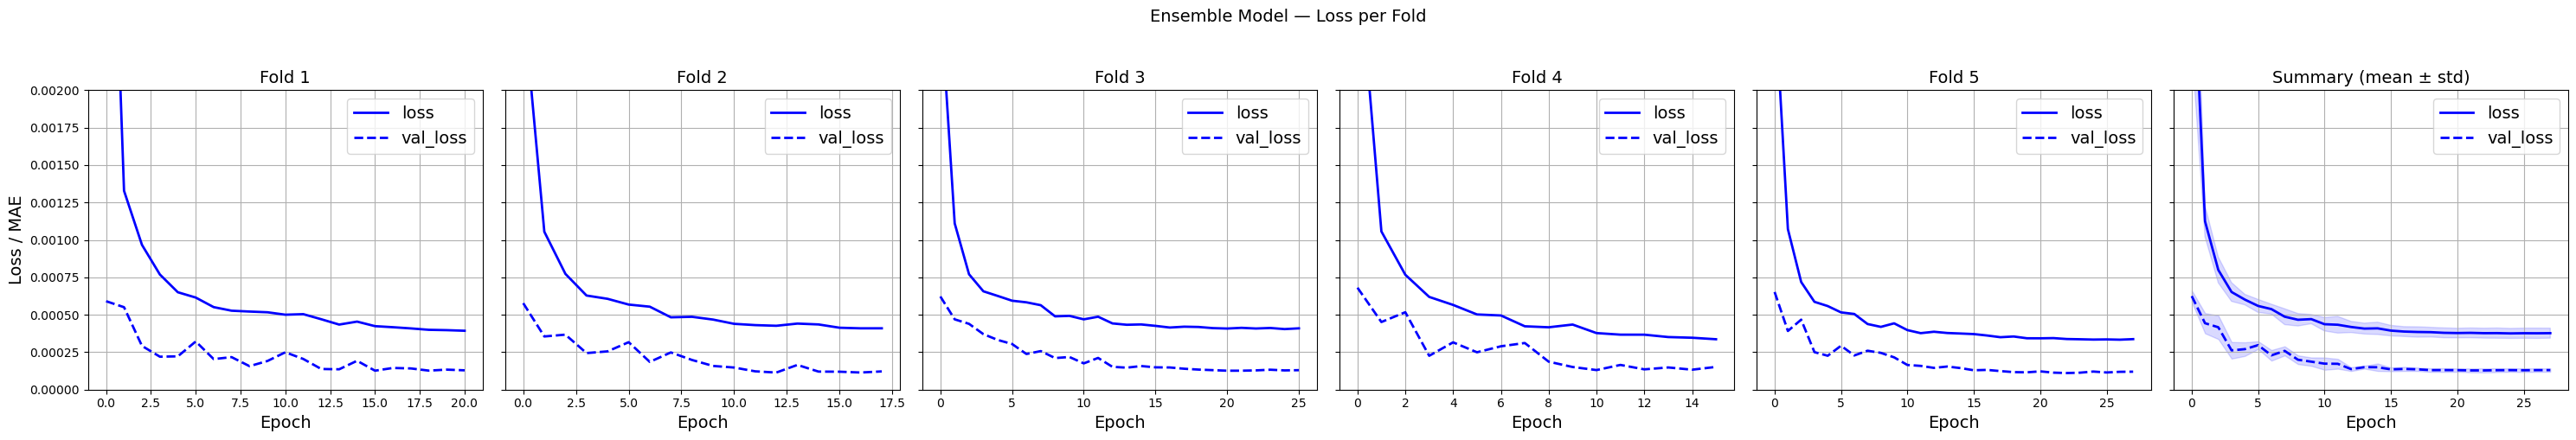

In [65]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.002))

In [66]:
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_test_y10)

3582/3582 [==============================] - 4s 1ms/step


In [67]:
# save the trained model:
root = "/pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_specsel_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/norm_params.json


/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/cnnpz_utils.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


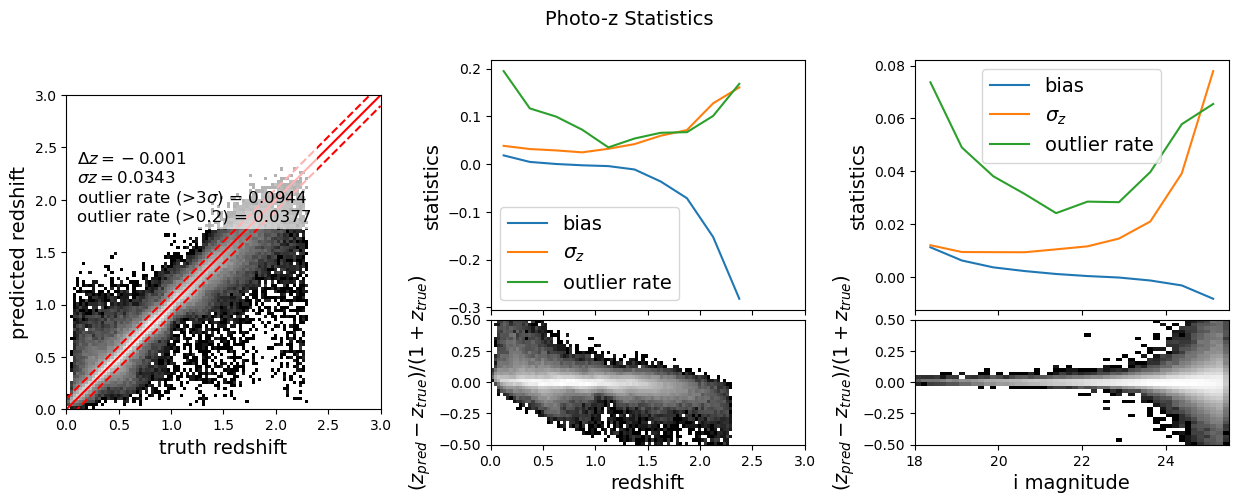

Plot saved to /pscratch/sd/j/jaimerz/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [68]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y10, y_pred_ensemble.flatten(), test_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y10, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

## Now include pre-training with the pop-cosmos data

In [69]:
# load pre-training data
fname = "/pscratch/sd/j/jaimerz/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y1.parquet"
pretraining_y1 = pd.read_parquet(fname)
# change the name of the roman columns:
pretraining_y1 = pretraining_y1.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

fname = "/pscratch/sd/j/jaimerz/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y10.parquet"
pretraining_y10 = pd.read_parquet(fname)
# change the name of the roman columns:
pretraining_y10 = pretraining_y10.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/j/jaimerz/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y1.parquet'

In [ ]:
# plot comparison in colour-redshift space:
fig,axarr=plt.subplots(1,3,figsize=[10,3],sharey=True)

for ii, colours in enumerate(['gr','ri','iz']):
    plt.sca(axarr[ii])
    ri = pretraining_y10[f'mag_{colours[0]}_lsst'] - pretraining_y10[f'mag_{colours[1]}_lsst']
    red = pretraining_y10['redshift']
    ind = pretraining_y10['mag_i_lsst'] < 25.4
    plt.scatter(red[ind][::50], ri[ind][::50], s=0.1, label="pre-training data")
    
    ri = training_y10[f'mag_{colours[0]}_lsst'] - training_y10[f'mag_{colours[1]}_lsst']
    red = training_y10['redshift']
    plt.scatter(red[::10], ri[::10], s=0.1, label="test data")
    
    plt.grid()
    plt.legend()
    plt.xlabel("redshift")
    plt.ylabel(f"{colours[0]}-{colours[1]}")
    plt.ylim([-1.5,5])

In [ ]:
# pre-training data:
pretraining_y10 = pretraining_y10[pretraining_y10['redshift']<2.4]
pretraining_y10 = pretraining_y10.sample(frac=0.5)
pretraining_y10 = pretraining_y10.reset_index(drop=True)
X_y10_pre, Y_y10_pre = cnnpz.transform_data_to_XY(pretraining_y10, lambda_array_cen, filter_blocks, apply_stretch=False)

In [ ]:
Y_y10_pre.dtype, Y_y10_spec.dtype

In [ ]:
len(Y_y10_pre)

In [ ]:
cnnpz.visualize_the_data(X_y10_pre, Y_y10_pre, lambda_array_cen, filter_blocks, title="Y10 pre-training example")

In [ ]:
trained_models, histories = cnnpz.train_ensembles(build_model, X_y10_pre, Y_y10_pre)

In [ ]:
cnnpz.plot_ensemble_losses(histories, ylim=(0, 0.005))

In [ ]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_pretrain_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models, save_dir=save_dir)

In [ ]:
# load this model
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_pretrain_ensemble_CNN_6layers"
trained_models = cnnpz.load_ensemble(save_dir=save_dir)

In [ ]:
# check pre-training performance
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models, X_y10_pre)

In [ ]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_y10_pre, y_pred_ensemble.flatten(), 
                                                     pretraining_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_y10_pre, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, pretraining_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

In [ ]:
trained_models_finetune, histories_finetune = cnnpz.fine_tune_pre_trained_model(X_y10_spec, Y_y10_spec, 
                                                pretrained_models = trained_models, 
                                                model_root = "", nlayers_forzen = 4)

In [ ]:
cnnpz.plot_ensemble_losses(histories_finetune, ylim=(0, 0.05))

In [ ]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_finetune_ensemble_CNN_6layers"
cnnpz.save_ensemble(trained_models_finetune, save_dir=save_dir)

In [ ]:
y_pred_ensemble, y_pred_STD = cnnpz.ensemble_predict(trained_models_finetune, X_test_y10)

In [ ]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = cnnpz.get_all_stats(Y_test_y10, y_pred_ensemble.flatten(), test_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

cnnpz.plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y10, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')